In [1]:
# ============================================================
# Verificacion del entorno
# ============================================================
import pyspark
import pandas as pd
import matplotlib
import sklearn
import numpy as np

print(f"PySpark:      {pyspark.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Matplotlib:   {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"NumPy:        {np.__version__}")

PySpark:      3.5.0
Pandas:       2.0.3
Matplotlib:   3.8.0
Scikit-learn: 1.3.1
NumPy:        1.24.4


In [2]:
# ============================================================
# Iniciar SparkSession
# ============================================================
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Bloque1_EDA")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version: {spark.version}")
print("SparkSession lista.")

Spark version: 3.5.0
SparkSession lista.


In [3]:
# ============================================================
# Muestra de 10 filas del SECOP II para ver columnas reales
# ============================================================
url_muestra = (
    "https://www.datos.gov.co/resource/jbjy-vk9h.csv"
    "?$limit=10"
)

muestra = pd.read_csv(url_muestra)
print(f"Columnas: {len(muestra.columns)}")
print(f"Filas:    {len(muestra)}\n")

for i, col in enumerate(muestra.columns, 1):
    print(f"  {i:2d}. {col}")

Columnas: 84
Filas:    10

   1. nombre_entidad
   2. nit_entidad
   3. departamento
   4. ciudad
   5. localizaci_n
   6. orden
   7. sector
   8. rama
   9. entidad_centralizada
  10. proceso_de_compra
  11. id_contrato
  12. referencia_del_contrato
  13. estado_contrato
  14. codigo_de_categoria_principal
  15. descripcion_del_proceso
  16. tipo_de_contrato
  17. modalidad_de_contratacion
  18. justificacion_modalidad_de
  19. fecha_de_firma
  20. fecha_de_inicio_del_contrato
  21. fecha_de_fin_del_contrato
  22. condiciones_de_entrega
  23. tipodocproveedor
  24. documento_proveedor
  25. proveedor_adjudicado
  26. es_grupo
  27. es_pyme
  28. habilita_pago_adelantado
  29. liquidaci_n
  30. obligaci_n_ambiental
  31. obligaciones_postconsumo
  32. reversion
  33. origen_de_los_recursos
  34. destino_gasto
  35. valor_del_contrato
  36. valor_de_pago_adelantado
  37. valor_facturado
  38. valor_pendiente_de_pago
  39. valor_pagado
  40. valor_amortizado
  41. valor_pendiente_de
  4

In [4]:
# ============================================================
# Ver los valores de cada columna para entender qué hay
# ============================================================
print(muestra.head(3).T.to_string())

                                                                                                                                                                                                                                                                                                                                        0                                                                                                                                                     1                                                                                                                                                                                                                                                                                                                                                         2
nombre_entidad                                                                                                                                                                

In [5]:
# ============================================================
# Descarga del dataset SECOP II — contratos 2024
# ============================================================
import os
import time
import requests
from io import StringIO

# Columnas que vamos a usar
columnas = [
    "nombre_entidad", "departamento", "sector", "orden", "rama",
    "entidad_centralizada", "tipo_de_contrato", "modalidad_de_contratacion",
    "estado_contrato", "es_pyme", "destino_gasto",
    "valor_del_contrato", "valor_pagado",
    "fecha_de_firma", "fecha_de_inicio_del_contrato", "fecha_de_fin_del_contrato",
    "objeto_del_contrato", "descripcion_del_proceso"
]

select_str = ",".join(columnas)
ARCHIVO = "../datos/secop_contratos.csv"

if not os.path.exists(ARCHIVO):
    print("Descargando contratos del SECOP II...")

    # Usamos requests con params para que codifique bien la URL
    base_url = "https://www.datos.gov.co/resource/jbjy-vk9h.csv"
    params = {
        "$select": select_str,
        "$where": "fecha_de_firma >= '2024-01-01T00:00:00.000'",
        "$limit": 60000,
        "$order": "fecha_de_firma DESC"
    }

    t0 = time.time()
    resp = requests.get(base_url, params=params, timeout=120)
    resp.raise_for_status()
    t1 = time.time()

    df_descarga = pd.read_csv(StringIO(resp.text))
    print(f"Descargados: {len(df_descarga):,} filas en {t1-t0:.1f} seg")
    print(f"Columnas:    {len(df_descarga.columns)}")

    # Si no alcanza con 2024, ampliamos a 2023
    if len(df_descarga) < 50000:
        print(f"\nSolo {len(df_descarga):,} filas con filtro 2024. Ampliando a 2023-2024...")
        params["$where"] = "fecha_de_firma >= '2023-01-01T00:00:00.000'"

        resp2 = requests.get(base_url, params=params, timeout=180)
        resp2.raise_for_status()
        df_descarga = pd.read_csv(StringIO(resp2.text))
        print(f"Descargados: {len(df_descarga):,} filas (2023-2024)")

    os.makedirs("../datos", exist_ok=True)
    df_descarga.to_csv(ARCHIVO, index=False)
    print(f"\nGuardado en {ARCHIVO}")
    print(f"Tamaño: {os.path.getsize(ARCHIVO) / 1024 / 1024:.1f} MB")
else:
    print(f"Archivo existente: {ARCHIVO}")
    df_descarga = pd.read_csv(ARCHIVO)
    print(f"Filas: {len(df_descarga):,}")

# Vista rapida
print(f"\n--- Resumen ---")
print(f"Filas: {len(df_descarga):,}")
print(f"Columnas: {len(df_descarga.columns)}")
print(f"\nModalidades de contratacion encontradas:")
print(df_descarga["modalidad_de_contratacion"].value_counts())

Archivo existente: ../datos/secop_contratos.csv
Filas: 60,000

--- Resumen ---
Filas: 60,000
Columnas: 18

Modalidades de contratacion encontradas:
modalidad_de_contratacion
Contratación régimen especial                                  28450
Mínima cuantía                                                 16757
Contratación directa                                            6358
Contratación régimen especial (con ofertas)                     2944
Selección Abreviada de Menor Cuantía                            2325
Selección abreviada subasta inversa                             1527
Licitación pública                                               514
Concurso de méritos abierto                                      470
Licitación pública Obra Publica                                  264
Contratación Directa (con ofertas)                               256
Licitación Pública Acuerdo Marco de Precios                      103
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes       1

---
## 1. Carga del dataset y diagnóstico de calidad

El dataset contiene 60,000 contratos del SECOP II (Sistema Electrónico de Contratación Pública) correspondientes a contratos firmados durante 2024. Se descargó desde la API Socrata de datos.gov.co, seleccionando 18 columnas relevantes para el análisis de un total de 84 disponibles.

In [6]:
# ============================================================
# Carga del CSV en PySpark
# ============================================================
df = spark.read.csv(
    "../datos/secop_contratos.csv",
    header=True,
    inferSchema=True,
    multiLine=True,
    encoding="UTF-8"
)

print(f"Registros: {df.count():,}")
print(f"Columnas:  {len(df.columns)}")
print("\n--- Esquema ---")
df.printSchema()

Registros: 60,000
Columnas:  18

--- Esquema ---
root
 |-- nombre_entidad: string (nullable = true)
 |-- departamento: string (nullable = true)
 |-- sector: string (nullable = true)
 |-- orden: string (nullable = true)
 |-- rama: string (nullable = true)
 |-- entidad_centralizada: string (nullable = true)
 |-- tipo_de_contrato: string (nullable = true)
 |-- modalidad_de_contratacion: string (nullable = true)
 |-- estado_contrato: string (nullable = true)
 |-- es_pyme: string (nullable = true)
 |-- destino_gasto: string (nullable = true)
 |-- valor_del_contrato: long (nullable = true)
 |-- valor_pagado: long (nullable = true)
 |-- fecha_de_firma: timestamp (nullable = true)
 |-- fecha_de_inicio_del_contrato: timestamp (nullable = true)
 |-- fecha_de_fin_del_contrato: timestamp (nullable = true)
 |-- objeto_del_contrato: string (nullable = true)
 |-- descripcion_del_proceso: string (nullable = true)



In [7]:
# ============================================================
# Vista de las primeras filas
# ============================================================
df.show(5, truncate=60)

+---------------------------------------------------+--------------------------+-------------------------+-----------+---------+--------------------+-----------------------+-----------------------------+---------------+-------+-------------+------------------+------------+-------------------+----------------------------+-------------------------+------------------------------------------------------------+------------------------------------------------------------+
|                                     nombre_entidad|              departamento|                   sector|      orden|     rama|entidad_centralizada|       tipo_de_contrato|    modalidad_de_contratacion|estado_contrato|es_pyme|destino_gasto|valor_del_contrato|valor_pagado|     fecha_de_firma|fecha_de_inicio_del_contrato|fecha_de_fin_del_contrato|                                         objeto_del_contrato|                                     descripcion_del_proceso|
+---------------------------------------------------+-----

In [8]:
# ============================================================
# Diagnostico de calidad: nulos reales + nulos disfrazados
# ============================================================
from pyspark.sql.functions import col, when, count, sum as spark_sum, lit

total = df.count()

# Contar nulos reales (null/NaN) y "No Definido"/"No definido" por columna
print(f"Total registros: {total:,}\n")
print(f"{'Columna':<35} {'Nulos':>8} {'No Def.':>8} {'% vacío':>8}")
print("-" * 65)

for c in df.columns:
    nulos = df.filter(col(c).isNull()).count()
    no_def = df.filter(
        (col(c) == "No Definido") |
        (col(c) == "No definido") |
        (col(c) == "Sin Descripcion")
    ).count()
    pct = (nulos + no_def) / total * 100
    if nulos > 0 or no_def > 0:
        print(f"{c:<35} {nulos:>8,} {no_def:>8,} {pct:>7.1f}%")

Total registros: 60,000

Columna                                Nulos  No Def.  % vacío
-----------------------------------------------------------------
departamento                               0    2,570     4.3%
tipo_de_contrato                           0        8     0.0%
destino_gasto                              0   19,753    32.9%
fecha_de_inicio_del_contrato           6,992        0    11.7%
objeto_del_contrato                        0      114     0.2%
descripcion_del_proceso                    0      141     0.2%


In [9]:
# ============================================================
# Verificacion de duplicados
# ============================================================
total_filas = df.count()
filas_distintas = df.distinct().count()
duplicados = total_filas - filas_distintas

print(f"Filas totales:   {total_filas:,}")
print(f"Filas distintas: {filas_distintas:,}")
print(f"Duplicados:      {duplicados:,} ({duplicados/total_filas*100:.2f}%)")

Filas totales:   60,000
Filas distintas: 52,832
Duplicados:      7,168 (11.95%)


---
## 2. Limpieza y preparación de los datos

Se eliminan duplicados exactos, se reemplazan valores placeholder ("No Definido", "Sin Descripcion") por nulos reales, y se crean variables derivadas para enriquecer el análisis.

In [10]:
# ============================================================
# Limpieza del dataset
# ============================================================
from pyspark.sql.functions import (
    col, when, datediff, year, month, trim, regexp_replace
)

# 1. Eliminar duplicados exactos
df_clean = df.dropDuplicates()
print(f"Antes:   {df.count():,} filas")
print(f"Despues: {df_clean.count():,} filas (se eliminaron {df.count() - df_clean.count():,} duplicados)")

# 2. Reemplazar "No Definido", "No definido", "Sin Descripcion" por null
valores_nulos = ["No Definido", "No definido", "Sin Descripcion"]

for c in df_clean.columns:
    if df_clean.schema[c].dataType.simpleString() == "string":
        df_clean = df_clean.withColumn(
            c,
            when(col(c).isin(valores_nulos), None).otherwise(col(c))
        )

print("\nValores placeholder reemplazados por null.")

# 3. Crear variables derivadas
df_clean = df_clean.withColumn(
    "duracion_dias",
    datediff(col("fecha_de_fin_del_contrato"), col("fecha_de_inicio_del_contrato"))
)

df_clean = df_clean.withColumn("anio_firma", year(col("fecha_de_firma")))
df_clean = df_clean.withColumn("mes_firma", month(col("fecha_de_firma")))

print("Variables derivadas creadas: duracion_dias, anio_firma, mes_firma")
print(f"\nDataset limpio: {df_clean.count():,} filas, {len(df_clean.columns)} columnas")

Antes:   60,000 filas
Despues: 52,832 filas (se eliminaron 7,168 duplicados)

Valores placeholder reemplazados por null.
Variables derivadas creadas: duracion_dias, anio_firma, mes_firma

Dataset limpio: 52,832 filas, 21 columnas


In [11]:
# ============================================================
# Verificacion post-limpieza: nulos reales
# ============================================================
total_clean = df_clean.count()

print(f"Dataset limpio: {total_clean:,} filas\n")
print(f"{'Columna':<35} {'Nulos':>8} {'%':>7}")
print("-" * 55)

for c in df_clean.columns:
    nulos = df_clean.filter(col(c).isNull()).count()
    if nulos > 0:
        print(f"{c:<35} {nulos:>8,} {nulos/total_clean*100:>6.1f}%")

print(f"\n--- Estadisticas de variables nuevas ---")
df_clean.select("duracion_dias", "anio_firma", "mes_firma").describe().show()

Dataset limpio: 52,832 filas

Columna                                Nulos       %
-------------------------------------------------------
departamento                           2,256    4.3%
tipo_de_contrato                           8    0.0%
destino_gasto                         17,866   33.8%
fecha_de_inicio_del_contrato           6,399   12.1%
objeto_del_contrato                      112    0.2%
descripcion_del_proceso                  139    0.3%
duracion_dias                          6,399   12.1%

--- Estadisticas de variables nuevas ---
+-------+------------------+----------+------------------+
|summary|     duracion_dias|anio_firma|         mes_firma|
+-------+------------------+----------+------------------+
|  count|             46433|     52832|             52832|
|   mean|146.38054831692978|    2026.0|3.3802619624470016|
| stddev|164.74729409125445|       0.0|1.0511023062811606|
|    min|                 0|      2026|                 2|
|    max|              7875|      2

In [12]:
# ============================================================
# Estadistica descriptiva general — variables numericas
# ============================================================
# describe() y summary() sobre las variables numericas principales

print("=== describe() ===")
df_clean.select("valor_del_contrato", "valor_pagado", "duracion_dias") \
    .describe().show()

print("=== summary() ===")
df_clean.select("valor_del_contrato", "valor_pagado", "duracion_dias") \
    .summary("count", "min", "25%", "50%", "75%", "max", "stddev") \
    .show()

=== describe() ===
+-------+--------------------+-------------------+------------------+
|summary|  valor_del_contrato|       valor_pagado|     duracion_dias|
+-------+--------------------+-------------------+------------------+
|  count|               52832|              52832|             46433|
|   mean|3.1148169815749925E8|  5511874.866766354|146.38054831692978|
| stddev| 3.784090053151645E9|9.821337637187313E7|164.74729409125445|
|    min|                   0|                  0|                 0|
|    max|        511743141447|        13484994408|              7875|
+-------+--------------------+-------------------+------------------+

=== summary() ===
+-------+-------------------+-------------------+------------------+
|summary| valor_del_contrato|       valor_pagado|     duracion_dias|
+-------+-------------------+-------------------+------------------+
|  count|              52832|              52832|             46433|
|    min|                  0|                  0|       

In [13]:
# ============================================================
# Conteos por categoria — variables categoricas principales
# ============================================================
from pyspark.sql.functions import desc
categoricas = [
    "sector", "modalidad_de_contratacion", "tipo_de_contrato",
    "departamento", "orden", "rama", "es_pyme", "destino_gasto"
]

for var in categoricas:
    n_cats = df_clean.select(var).distinct().count()
    print(f"\n{'='*50}")
    print(f"{var} ({n_cats} categorias)")
    print(f"{'='*50}")
    df_clean.groupBy(var).count().orderBy(desc("count")).show(5, truncate=35)


sector (25 categorias)
+-------------------------+-----+
|                   sector|count|
+-------------------------+-----+
|Salud y Protección Social|22135|
|         Servicio Público| 9810|
|   No aplica/No pertenece| 6775|
|                  defensa| 4683|
|          Ley de Justicia| 1606|
+-------------------------+-----+
only showing top 5 rows


modalidad_de_contratacion (14 categorias)
+-----------------------------------+-----+
|          modalidad_de_contratacion|count|
+-----------------------------------+-----+
|      Contratación régimen especial|21766|
|                     Mínima cuantía|16748|
|               Contratación directa| 6099|
|Contratación régimen especial (c...| 2819|
|Selección Abreviada de Menor Cua...| 2325|
+-----------------------------------+-----+
only showing top 5 rows


tipo_de_contrato (22 categorias)
+-----------------------+-----+
|       tipo_de_contrato|count|
+-----------------------+-----+
|Prestación de servicios|30119|
|            Sumini

---
## 3. Transformaciones analíticas

Se aplican cuatro transformaciones de PySpark para responder preguntas concretas sobre la contratación pública colombiana.

In [14]:
# ============================================================
# TRANSFORMACION 1: filter
# Pregunta: ¿Como se distribuye la modalidad de contratacion
# dentro de los contratos de Prestacion de servicios?
# ============================================================
from pyspark.sql.functions import count, desc, round as spark_round

# Filtrar solo contratos de "Prestacion de servicios"
df_servicios = df_clean.filter(col("tipo_de_contrato") == "Prestación de servicios")

total_servicios = df_servicios.count()
print(f"Contratos de 'Prestacion de servicios': {total_servicios:,}")
print(f"({total_servicios / df_clean.count() * 100:.1f}% del total)\n")

# Distribucion de modalidad dentro de ese filtro
df_servicios.groupBy("modalidad_de_contratacion") \
    .agg(
        count("*").alias("n_contratos"),
        spark_round(count("*") / total_servicios * 100, 1).alias("porcentaje")
    ) \
    .orderBy(desc("n_contratos")) \
    .show(truncate=False)

Contratos de 'Prestacion de servicios': 30,119
(57.0% del total)

+-----------------------------------------------------------+-----------+----------+
|modalidad_de_contratacion                                  |n_contratos|porcentaje|
+-----------------------------------------------------------+-----------+----------+
|Contratación régimen especial                              |14132      |46.9      |
|Mínima cuantía                                             |7854       |26.1      |
|Contratación directa                                       |5702       |18.9      |
|Selección Abreviada de Menor Cuantía                       |1237       |4.1       |
|Contratación régimen especial (con ofertas)                |484        |1.6       |
|Licitación pública                                         |359        |1.2       |
|Selección abreviada subasta inversa                        |343        |1.1       |
|Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes|8          |0.0       |

In [15]:
# ============================================================
# TRANSFORMACION 2: groupBy
# Pregunta: ¿Cual es el valor promedio y mediano de contratos
# por sector? ¿Que sectores concentran mas gasto?
# ============================================================
from pyspark.sql.functions import (
    avg, sum as spark_sum, percentile_approx, format_number
)

resumen_sector = df_clean.groupBy("sector") \
    .agg(
        count("*").alias("n_contratos"),
        spark_round(avg("valor_del_contrato"), 0).alias("valor_promedio"),
        percentile_approx("valor_del_contrato", 0.5).alias("valor_mediano"),
        spark_sum("valor_del_contrato").alias("valor_total")
    ) \
    .orderBy(desc("valor_total"))

print("Resumen por sector (ordenado por gasto total):\n")
resumen_sector.show(15, truncate=30)

Resumen por sector (ordenado por gasto total):

+------------------------------+-----------+--------------+-------------+-------------+
|                        sector|n_contratos|valor_promedio|valor_mediano|  valor_total|
+------------------------------+-----------+--------------+-------------+-------------+
|              Servicio Público|       9810|  4.45713504E8|     46115344|4372449475296|
|        No aplica/No pertenece|       6775|  4.66665734E8|     40008500|3161660345461|
|     Salud y Protección Social|      22135|   8.6785549E7|     13387500|1920998131339|
|                    Transporte|        534| 3.002610775E9|     56262015|1603394154054|
|                       defensa|       4683|  2.08793808E8|     31569600| 977781405171|
| Vivienda, Ciudad y Territorio|        530| 1.139036343E9|    124678697| 603689261628|
|               Minas y Energía|         89| 6.662632331E9|     85474583| 592974277421|
|            Educación Nacional|       1540|  3.58457877E8|     31389266

In [16]:
# ============================================================
# TRANSFORMACION 3: withColumn
# Crear variable binaria: contratacion directa vs competitiva
# Esta variable sera relevante para el Bloque 2 (ML)
# ============================================================

# Modalidades que NO involucran competencia abierta
modalidades_directas = [
    "Contratación directa",
    "Contratación Directa (con ofertas)",
    "Contratación régimen especial",
    "Contratación régimen especial (con ofertas)"
]

df_clean = df_clean.withColumn(
    "es_directa",
    when(col("modalidad_de_contratacion").isin(modalidades_directas), 1).otherwise(0)
)

# Verificar distribucion
print("Distribucion de la variable es_directa:")
df_clean.groupBy("es_directa") \
    .agg(
        count("*").alias("n_contratos"),
        spark_round(avg("valor_del_contrato"), 0).alias("valor_promedio")
    ) \
    .show()

n_directa = df_clean.filter(col("es_directa") == 1).count()
n_total = df_clean.count()
print(f"Contratacion directa/regimen especial: {n_directa:,} ({n_directa/n_total*100:.1f}%)")
print(f"Proceso competitivo:                   {n_total - n_directa:,} ({(n_total-n_directa)/n_total*100:.1f}%)")

Distribucion de la variable es_directa:
+----------+-----------+--------------+
|es_directa|n_contratos|valor_promedio|
+----------+-----------+--------------+
|         1|      30940|   2.3522252E8|
|         0|      21892|  4.19258922E8|
+----------+-----------+--------------+

Contratacion directa/regimen especial: 30,940 (58.6%)
Proceso competitivo:                   21,892 (41.4%)


In [17]:
# ============================================================
# TRANSFORMACION 4: join
# Pregunta: ¿Como se compara el valor de cada contrato contra
# el promedio de su departamento?
# ============================================================

# Crear tabla de referencia: promedio por departamento
promedios_depto = df_clean \
    .filter(col("departamento").isNotNull()) \
    .groupBy("departamento") \
    .agg(
        avg("valor_del_contrato").alias("valor_promedio_depto"),
        count("*").alias("n_contratos_depto")
    )

# Join con el dataset original
df_clean = df_clean.join(promedios_depto, on="departamento", how="left")

# Crear ratio: valor del contrato / promedio del departamento
df_clean = df_clean.withColumn(
    "ratio_vs_depto",
    spark_round(col("valor_del_contrato") / col("valor_promedio_depto"), 2)
)

# Ver contratos que superan 10x el promedio de su departamento
atipicos_depto = df_clean.filter(col("ratio_vs_depto") > 10).count()
print(f"Contratos que superan 10x el promedio de su departamento: {atipicos_depto:,}")
print(f"({atipicos_depto / df_clean.count() * 100:.1f}% del total)\n")

# Top 5 departamentos por valor promedio
print("Top 10 departamentos por valor promedio de contrato:")
promedios_depto \
    .filter(col("n_contratos_depto") >= 100) \
    .orderBy(desc("valor_promedio_depto")) \
    .show(10, truncate=25)

Contratos que superan 10x el promedio de su departamento: 785
(1.5% del total)

Top 10 departamentos por valor promedio de contrato:
+-------------------------+--------------------+-----------------+
|             departamento|valor_promedio_depto|n_contratos_depto|
+-------------------------+--------------------+-----------------+
|                    Chocó|1.3054135146054795E9|              365|
|               La Guajira|  9.56909428035982E8|              667|
|                  Córdoba| 9.420889641948956E8|              431|
|                    Sucre| 6.009736289373134E8|              335|
|Distrito Capital de Bo...|  5.57940873615632E8|             8393|
|                    Cesar|4.5593152436764705E8|              884|
|          Valle del Cauca| 3.972895858212735E8|             2764|
|                Risaralda|3.8236988023883164E8|              582|
|                  Bolívar|3.8163337750031626E8|             1581|
|                Atlántico| 3.657421074976415E8|             16

---
## 4. Estadística descriptiva y detección de atípicos

Se reportan estadísticos de posición y forma para las variables numéricas principales, con énfasis en la distribución del valor de los contratos. Se identifican atípicos mediante el criterio del rango intercuartílico (IQR) y se respaldan las comparaciones entre grupos con una prueba no paramétrica.

In [18]:
# ============================================================
# Estadistica descriptiva — valor_del_contrato
# ============================================================
from pyspark.sql.functions import (
    stddev, min as spark_min, max as spark_max,
    percentile_approx, skewness, kurtosis
)

# Percentiles detallados
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
valores_pct = df_clean.select(
    percentile_approx("valor_del_contrato", percentiles).alias("pcts")
).collect()[0]["pcts"]

print("=== Distribucion de valor_del_contrato (COP) ===\n")

# Estadisticos basicos
stats = df_clean.select(
    count("valor_del_contrato").alias("n"),
    avg("valor_del_contrato").alias("media"),
    stddev("valor_del_contrato").alias("desv_est"),
    spark_min("valor_del_contrato").alias("minimo"),
    spark_max("valor_del_contrato").alias("maximo"),
    skewness("valor_del_contrato").alias("asimetria"),
    kurtosis("valor_del_contrato").alias("curtosis")
).collect()[0]

print(f"N:              {stats['n']:,}")
print(f"Media:          {stats['media']:,.0f}")
print(f"Desv. estandar: {stats['desv_est']:,.0f}")
print(f"Minimo:         {stats['minimo']:,}")
print(f"Maximo:         {stats['maximo']:,}")
print(f"Asimetria:      {stats['asimetria']:.2f}")
print(f"Curtosis:       {stats['curtosis']:.2f}")

print(f"\nPercentiles:")
for p, v in zip(percentiles, valores_pct):
    print(f"  P{int(p*100):>2}: {v:>20,}")

# Coeficiente de variacion
cv = stats['desv_est'] / stats['media'] * 100
print(f"\nCoef. de variacion: {cv:.1f}%")

if stats['asimetria'] > 2:
    print(f"\nNota: Asimetria de {stats['asimetria']:.2f} confirma distribucion")
    print("de cola pesada. La mediana es mas representativa que la media.")

=== Distribucion de valor_del_contrato (COP) ===

N:              52,832
Media:          311,481,698
Desv. estandar: 3,784,090,053
Minimo:         0
Maximo:         511,743,141,447
Asimetria:      72.94
Curtosis:       7948.89

Percentiles:
  P 1:            1,035,440
  P 5:            3,044,950
  P10:            5,082,800
  P25:           10,212,147
  P50:           24,500,000
  P75:           59,999,800
  P90:          323,000,000
  P95:          801,296,020
  P99:        4,488,716,626

Coef. de variacion: 1214.9%

Nota: Asimetria de 72.94 confirma distribucion
de cola pesada. La mediana es mas representativa que la media.


In [19]:
# ============================================================
# Deteccion de atipicos — criterio IQR (Tukey)
# ============================================================
# Q1, Q3 e IQR sobre valor_del_contrato
q1, q3 = df_clean.select(
    percentile_approx("valor_del_contrato", [0.25, 0.75])
).collect()[0][0]

iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

n_total = df_clean.count()
n_atipicos_sup = df_clean.filter(col("valor_del_contrato") > limite_superior).count()
n_atipicos_inf = df_clean.filter(col("valor_del_contrato") < limite_inferior).count()

print("=== Deteccion de atipicos (criterio IQR x 1.5) ===\n")
print(f"Q1:              {q1:>20,}")
print(f"Q3:              {q3:>20,}")
print(f"IQR:             {iqr:>20,}")
print(f"Limite inferior: {limite_inferior:>20,}")
print(f"Limite superior: {limite_superior:>20,}")
print(f"\nAtipicos superiores: {n_atipicos_sup:,} ({n_atipicos_sup/n_total*100:.1f}%)")
print(f"Atipicos inferiores: {n_atipicos_inf:,} ({n_atipicos_inf/n_total*100:.1f}%)")

# Tambien para duracion_dias (excluyendo nulos)
df_dur = df_clean.filter(col("duracion_dias").isNotNull())
q1d, q3d = df_dur.select(
    percentile_approx("duracion_dias", [0.25, 0.75])
).collect()[0][0]

iqr_d = q3d - q1d
lim_sup_d = q3d + 1.5 * iqr_d

n_dur_atip = df_dur.filter(col("duracion_dias") > lim_sup_d).count()
print(f"\n--- Atipicos en duracion_dias ---")
print(f"Q1: {q1d} dias | Q3: {q3d} dias | Limite: {lim_sup_d} dias")
print(f"Atipicos: {n_dur_atip:,} contratos con duracion > {lim_sup_d} dias")

=== Deteccion de atipicos (criterio IQR x 1.5) ===

Q1:                        10,212,147
Q3:                        59,999,800
IQR:                       49,787,653
Limite inferior:        -64,469,332.5
Limite superior:        134,681,279.5

Atipicos superiores: 8,540 (16.2%)
Atipicos inferiores: 0 (0.0%)

--- Atipicos en duracion_dias ---
Q1: 59 dias | Q3: 236 dias | Limite: 501.5 dias
Atipicos: 203 contratos con duracion > 501.5 dias


In [20]:
# ============================================================
# Comparacion estadistica: valor de contratos
# directa vs competitiva (prueba no parametrica)
# ============================================================
# Usamos Mann-Whitney porque la distribucion no es normal
# (asimetria >> 0, cola pesada)

from scipy.stats import mannwhitneyu

# Extraer muestras a Pandas (muestra aleatoria para eficiencia)
muestra_directa = (
    df_clean.filter(col("es_directa") == 1)
    .select("valor_del_contrato")
    .sample(fraction=0.1, seed=42)
    .toPandas()["valor_del_contrato"]
)

muestra_competitiva = (
    df_clean.filter(col("es_directa") == 0)
    .select("valor_del_contrato")
    .sample(fraction=0.1, seed=42)
    .toPandas()["valor_del_contrato"]
)

stat, p_value = mannwhitneyu(
    muestra_directa, muestra_competitiva, alternative='two-sided'
)

print("=== Prueba de Mann-Whitney U ===")
print("H0: La distribucion de valores es igual entre contratos")
print("    directos y competitivos.")
print(f"\nMediana directa:     {muestra_directa.median():>15,.0f} COP")
print(f"Median competitiva:  {muestra_competitiva.median():>15,.0f} COP")
print(f"\nEstadistico U: {stat:,.0f}")
print(f"p-value:       {p_value:.2e}")

if p_value < 0.05:
    print("\nResultado: Se rechaza H0 (p < 0.05). Existe diferencia")
    print("estadisticamente significativa en los valores de contratos")
    print("entre modalidades directas y competitivas.")
else:
    print("\nResultado: No se rechaza H0.")

=== Prueba de Mann-Whitney U ===
H0: La distribucion de valores es igual entre contratos
    directos y competitivos.

Mediana directa:          17,267,250 COP
Median competitiva:       42,258,937 COP

Estadistico U: 2,314,214
p-value:       1.32e-100

Resultado: Se rechaza H0 (p < 0.05). Existe diferencia
estadisticamente significativa en los valores de contratos
entre modalidades directas y competitivas.


---
## 5. Visualizaciones

Se presentan dos visualizaciones construidas sobre datos convertidos a Pandas. Ambas tienen el objetivo de respaldar hallazgos cuantitativos del análisis, no son meramente descriptivas.

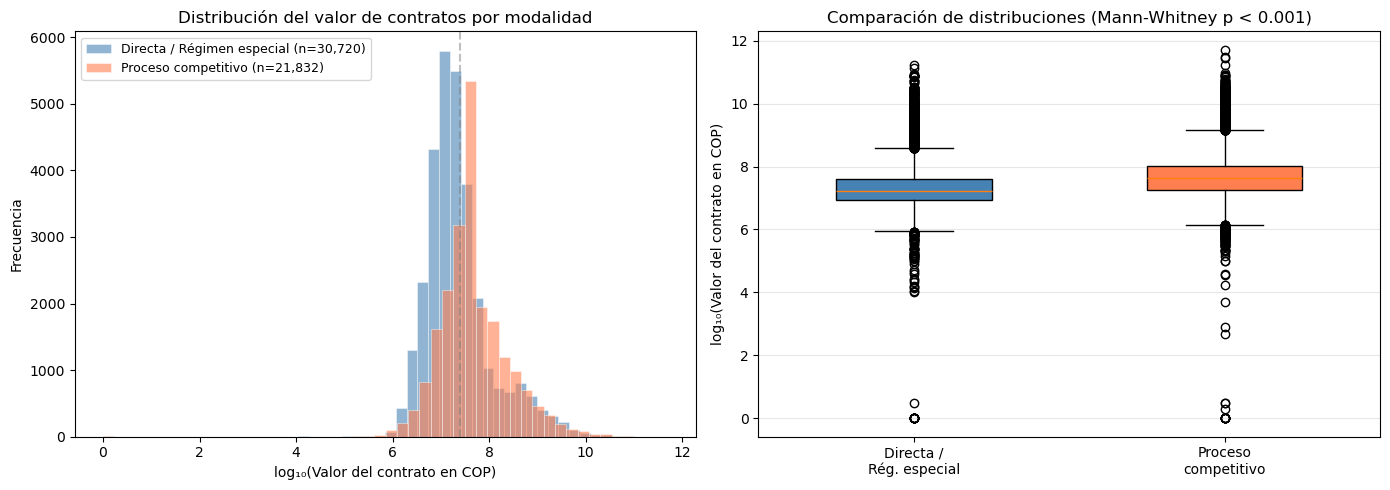

Figura guardada en bloque1_eda/fig1_distribucion_modalidad.png


In [21]:
# ============================================================
# VISUALIZACION 1: Distribucion de valores por modalidad
# (escala logaritmica — directa vs competitiva)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Convertir a Pandas (muestra representativa para graficar)
df_viz1 = (
    df_clean
    .filter(col("valor_del_contrato") > 0)
    .select("valor_del_contrato", "es_directa")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma en escala log
for grupo, label, color in [(1, "Directa / Régimen especial", "steelblue"),
                             (0, "Proceso competitivo", "coral")]:
    datos = df_viz1[df_viz1["es_directa"] == grupo]["valor_del_contrato"]
    axes[0].hist(np.log10(datos), bins=50, alpha=0.6,
                 label=f"{label} (n={len(datos):,})", color=color,
                 edgecolor="white", linewidth=0.5)

axes[0].set_xlabel("log₁₀(Valor del contrato en COP)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución del valor de contratos por modalidad")
axes[0].legend(fontsize=9)
axes[0].axvline(np.log10(24_500_000), color="gray", linestyle="--",
                alpha=0.5, label="Mediana global")

# Box plot comparativo (log)
datos_box = [
    np.log10(df_viz1[df_viz1["es_directa"] == 1]["valor_del_contrato"]),
    np.log10(df_viz1[df_viz1["es_directa"] == 0]["valor_del_contrato"])
]
bp = axes[1].boxplot(datos_box, labels=["Directa /\nRég. especial", "Proceso\ncompetitivo"],
                     patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("coral")
axes[1].set_ylabel("log₁₀(Valor del contrato en COP)")
axes[1].set_title("Comparación de distribuciones (Mann-Whitney p < 0.001)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../bloque1_eda/fig1_distribucion_modalidad.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figura guardada en bloque1_eda/fig1_distribucion_modalidad.png")

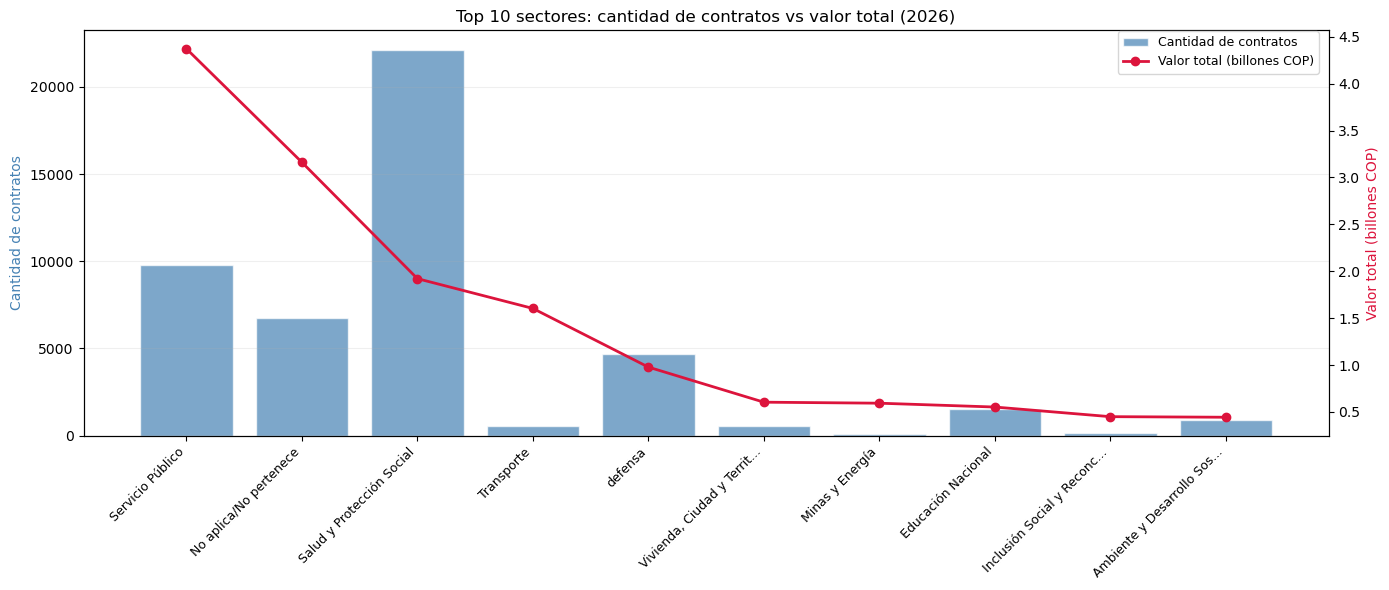

Figura guardada en bloque1_eda/fig2_sectores.png


In [22]:
# ============================================================
# VISUALIZACION 2: Top 10 sectores por volumen de contratacion
# Doble eje: cantidad de contratos + valor total
# ============================================================

# Datos agregados por sector (ya los tenemos de la celda 16)
df_viz2 = (
    df_clean
    .groupBy("sector")
    .agg(
        count("*").alias("n_contratos"),
        spark_sum("valor_del_contrato").alias("valor_total"),
        avg("valor_del_contrato").alias("valor_promedio"),
        percentile_approx("valor_del_contrato", 0.5).alias("valor_mediano")
    )
    .orderBy(desc("valor_total"))
    .limit(10)
    .toPandas()
)

# Acortar nombres largos para la grafica
df_viz2["sector_corto"] = df_viz2["sector"].apply(
    lambda x: x[:25] + "..." if len(str(x)) > 25 else x
)

fig, ax1 = plt.subplots(figsize=(14, 6))

x = range(len(df_viz2))
barras = ax1.bar(x, df_viz2["n_contratos"], color="steelblue",
                 alpha=0.7, edgecolor="white", label="Cantidad de contratos")
ax1.set_ylabel("Cantidad de contratos", color="steelblue")
ax1.set_xticks(x)
ax1.set_xticklabels(df_viz2["sector_corto"], rotation=45, ha="right", fontsize=9)

# Segundo eje: valor total en billones
ax2 = ax1.twinx()
ax2.plot(x, df_viz2["valor_total"] / 1e12, color="crimson",
         marker="o", linewidth=2, label="Valor total (billones COP)")
ax2.set_ylabel("Valor total (billones COP)", color="crimson")

ax1.set_title("Top 10 sectores: cantidad de contratos vs valor total (2026)")
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=9)
ax1.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("../bloque1_eda/fig2_sectores.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figura guardada en bloque1_eda/fig2_sectores.png")

---
## 6. Conclusiones cuantitativas**Conclusión 1 — Predominio de la contratación sin competencia abierta:**
El 58.6% de los contratos (30,940 de 52,832) se adjudican mediante contratación directa o régimen especial, sin proceso competitivo abierto. Esta proporción sube al 66.8% cuando se analizan solo los contratos de "Prestación de servicios", que representan el 57% del total. La mediana de valor en contratos directos es de 17.3 millones COP, significativamente menor que los 42.3 millones de los competitivos (prueba de Mann-Whitney, p < 0.001), lo que sugiere que los procesos competitivos se reservan para montos mayores, consistente con los umbrales legales de la contratación pública colombiana. La distribución entre ambas categorías (58.6% vs 41.4%) resulta lo suficientemente balanceada para abordar una clasificación supervisada sin requerir técnicas de rebalanceo artificiaes.ana.

**Conclusión 2 — Distribución de valores con cola pesada extrema:**
El valor de los contratos presenta una asimetría de 72.94 y una curtosis de 7,948.89, con un coeficiente de variación de 1,214.9%. La mediana (24.5 millones COP) es 12.7 veces menor que la media (311.5 millones), y el 16.2% de los contratos supera el límite superior del criterio IQR (134.7 millones COP). Esto implica que cualquier modelo predictivo sobre estos valores debe considerar transformaciones logarítmicas o métodos robustos a distribuciones de cola pesada.

**Conclusión 3 — Concentración sectorial del gasto público:**
El sector de Salud y Protección Social concentra la mayor cantidad de contratos (22,135, el 41.9%), pero solo el cuarto lugar en gasto total. En contraste, "Transporte" tiene apenas 534 contratos pero ocupa el cuarto lugar en gasto con 1.6 billones COP, lo que implica un valor mediano por contrato 4.6 veces mayor que el de Salud. Esta asimetría entre volumen de contratos y volumen de gasto revela estructuras de contratación fundamentalmente diferentes entre sectores.

In [23]:
# ============================================================
# Guardar dataset limpio para Bloque 2 (formato Parquet)
# ============================================================
df_clean.write.parquet(
    "../datos/secop_limpio.parquet",
    mode="overwrite"
)
print(f"Dataset guardado: {df_clean.count():,} filas, {len(df_clean.columns)} columnas")
print("Formato: Parquet (evita problemas con texto multilinea)")

Dataset guardado: 52,832 filas, 25 columnas
Formato: Parquet (evita problemas con texto multilinea)
